<a href="https://colab.research.google.com/github/smk00513/Intro_to_AI_ML_Basic/blob/main/ML_Assignment_1_Template.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 머신러닝 과제 템플릿: 데이터 특성에 따른 분류 모델 선택 및 적용

## 목적
- 제공된 **3개의 데이터셋**을 각각 분석하고, 각 데이터셋에 대해 아래 **3개 모델 중 1개**를 선택하여 학습 및 평가한다.
  - Logistic Regression
  - Decision Tree
  - Random Forest

## 과제 핵심
- **모델 성능 자체는 평가 대상이 아니다.**
- 데이터 특성에 기반하여 **왜 그 모델을 선택했는지**, 그리고 **나머지 두 모델을 선택하지 않은 이유**를 논리적으로 설명하는 것이 중요하다.

## 제출물
- `.ipynb` 파일 1개(이 노트북) 제출


## 작성 안내
- 각 섹션의 **Markdown 문장 뼈대**를 읽고, 본인의 분석/근거를 문장으로 채운다.
- 각 데이터셋마다 **모델 1개만** 선택하여 구현한다(세 모델을 자동 비교하는 코드는 작성하지 않는다).
- 필요 시 셀을 추가해도 되지만, 전체 구조는 유지한다.


In [ ]:
# 라이브러리 용도
# - numpy/pandas: 데이터 로딩 및 기본 처리
# - matplotlib/seaborn: 시각화(선택)
# - scikit-learn: 전처리, 모델, 평가
# 필요한 라이브러리가 있을 시 추가로 import 해서 쓰면 됩니다.
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
)

RANDOM_STATE = 42


---
# 데이터셋 1 (heart_disease)


## 1) 데이터셋 설명



- 데이터 출처/의미 : 환자의 임상 정보를 바탕으로 심장 질환의 유무 및 중증도를 예측하는 데이터입니다. 의학적 진단의 보조 지표로 활용될 수 있는 성격을 가집니다.

- 샘플 수 / 피처 수 : 303개의 샘플과 13개의 피처(타깃 변수 num 제외)로 구성되어 있습니다. 데이터의 규모가 크지 않아 모델의 복잡도를 세심하게 조절해야 합니다

- 타깃 변수(클래스) 설명 : **num** : 0(정상)부터 4(중증)까지의 범주를 가집니다.

- 데이터 타입 특징 : **혼합형 데이터** : 나이, 혈압 같은 연속형 수치 데이터와 성별, 흉통 유형 같은 범주형 데이터(int)가 혼합되어있습니다.

- 예상되는 어려움 : 콜레스테롤(chol) 등 일부 수치형 데이터에서 극단적인 값이 존재할 수 있어 선형 모델 선택 시 성능 저하가 발생할 수 있습니다(Outlier). 데이터 중간에 빈 값이 존재합니다(결측치).

## 2) 데이터 불러오기 및 기본 확인
- 파일 경로/형식(csv 등)과 로딩 방법을 설명한다.
- `shape`, `head()`, 결측치 개수, 타깃 분포 등을 확인하고 요약한다.


In [ ]:
DATASET1_PATH = "/content/sample_data/heart_disease.csv"

df1 = pd.read_csv(DATASET1_PATH)

display(df1.head())
print("shape:", df1.shape)
print("dtypes:\n", df1.dtypes)
print("missing values (sum):\n", df1.isna().sum().sort_values(ascending=False).head(10))


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
0,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0,0
1,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0,2
2,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0,1
3,37,1,3,130,250,0,0,187,0,3.5,3,0.0,3.0,0
4,41,0,2,130,204,0,2,172,0,1.4,1,0.0,3.0,0


shape: (303, 14)
dtypes:
 age           int64
sex           int64
cp            int64
trestbps      int64
chol          int64
fbs           int64
restecg       int64
thalach       int64
exang         int64
oldpeak     float64
slope         int64
ca          float64
thal        float64
num           int64
dtype: object
missing values (sum):
 ca          4
thal        2
cp          0
trestbps    0
age         0
sex         0
fbs         0
chol        0
restecg     0
thalach     0
dtype: int64


## 3) 전처리 과정 설명
- 수행한 전처리 내용을 작성한다.
- 각 전처리가 왜 필요한지 간단히 설명한다.
- 예: 결측치 처리, 범주형 변수 인코딩, 불필요한 변수 제거


In [ ]:
# 1. 타깃 변수(num) 이진 분류 변환 (0: 정상, 1: 질환)
# 원본의 1, 2, 3, 4를 1로 통합
df1['num'] = df1['num'].apply(lambda x: 1 if x > 0 else 0)

# 피처 타깃 분리
X = df1.drop('num', axis=1)
y = df1['num']

# 2. 데이터 타입별 컬럼 분류
# 수치형 변수
numeric_features = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
# 범주형 변수(ca, thal은 결측치가 있으므로 포함)
categorical_features = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']

# 3. 수치형 데이터 전처리 파이프라인
# SimpleImputer: 수치형 결측치 median으로 대체
# StandardScaler: 평균 0, 표준편차 1로 스케일 조정
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# 4. 범주형 데이터 전처리 파이프라인
# SimpleImputer: 범주형 결측치 most_frequent로 대체
# OneHotEncoder: 숫자의 크기 정보가 모델에 왜곡을 주지 않도록 함
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# 5. 전처리 프로세서 통합
# 각 컬럼 타입에 맞는 전처리 자동 적용 설정
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

# 6. 데이터 분할 (학습 8, 테스트 2)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE)

print("전처리 준비 완료")
print(f"학습 데이터 크기: {X_train.shape}")
print(f"테스트 데이터 크기: {X_test.shape}")




# 전처리 과정 설명
# 타겟 변수 이진화 :
# num 열의 값을 0과 1로 단순화하여 이진 분류 문제로 정의
# Logistic Regression이 확률 기반 이진 분류 모델이므로 이에 적합한 형태로 변환

# 결측치 처리 :
# 데이터에 포함된 NaN 값을 각 변수의 특성에 맞춰 median or most_frequent로 채워 에러 방지
# 모델 학습 시 오류를 방지하고, 작은 데이터셋에서 데이터 손실 최소화

# 원-핫 인코딩 :
# 숫자로 표기된 범주형 변수를 독립된 열로 분리하여, 모델이 잘못된 선형 관계 학습을 방지

# 데이터 스케일링 : age, trestbps, chol 등 수치가 큰 변수들이 과도한 가중치를 갖지 않도록, 표준화(StandardScaler)하여 모델이 모든 변수를 균등하게 반영

전처리 준비 완료
학습 데이터 크기: (242, 13)
테스트 데이터 크기: (61, 13)


## 4) 모델 선택 설명



선택한 모델 : Logistic Regression
- 선택 이유
  - 데이터 규모 및 모델 복잡도 : 샘플 수가 303개로 소규모 데이터셋이므로, 파라미터 수가 적은 Logistic Regression이 다른 고차원 모델에 비해 Overfitting 발생 가능성이 낮으며 일반화 성능이 좋습니다.
  - 선형적 분리 가능성 : age, trestbps, thalach 등 주요 수치형 독립 변수들과 타깃 변수 간의 상관관계가 존재할 때, 모델이 선형 결정 경계를 생성하므로 효율적인 분류 평면을 구축할 수 있습니다. 또한, 수치형과 범주형이 혼합된 데이터 구조에서 변수 간의 선형 결합을 통해 안정적인 확률 추정이 가능합니다.
  - 해석 가능성 : 데이터가 의료 진단 보조를 목적으로 하므로, 각 피처의 coefficient와 Odds Ratio를 통해 특정 변수가 결과 확률에 미치는 영향력을 정량적으로 설명할 수 있는 모델이 적합하다고 판단했습니다.

- 선택하지 않은 모델 1 : Decision Tree
  - 선택하지 않은 이유 : 결정 트리는 데이터의 국소적인 변동에 민감하고 계단식 결정 경계를 형성합니다. 데이터가 소규모이므로 트리가 깊어질수록 특정 샘플에 과하게 편향(Bias)될 수 있으며, 분산이 높아져 성능의 안정성이 떨어집니다.

- 선택하지 않은 모델 2 : Random Forest
  - 랜덤 포레스트는 Bagging을 통해 성능을 극대화 하는 모델이므로, 현재 데이터 규모에서는 모델의 복잡도가 데이터의 복잡도를 상회하여 불필요한 노이즈까지 학습할 수 있습니다. 또한 모델 내부의 의사결정 과정을 직관적으로 파악하기 어려워 피처 간의 직접적인 인과관계 및 영향력을 Logistic Regression 만큼 명확히 파악하기 어렵습니다.

## 5) 선택한 모델 구현
- 전처리 파이프라인과 결합하여 학습 가능한 형태로 구성한다.
- **주의:** 세 모델을 동시에 비교/튜닝하는 코드는 작성하지 않는다.


In [ ]:
# 1. 모델 선택
model_1 = LogisticRegression(random_state=RANDOM_STATE)

# 2. 전처리 파이프라인과 모델 결합
clf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', model_1)
])

# 3. 모델 학습
clf_pipeline.fit(X_train, y_train)

# 4. 예측 수행
y_pred = clf_pipeline.predict(X_test)

# 5. 결과 확인
print("### Dataset 1: Logistic Regression Results ###")
print(classification_report(y_test, y_pred))

### Dataset 1: Logistic Regression Results ###
              precision    recall  f1-score   support

           0       0.83      0.83      0.83        29
           1       0.84      0.84      0.84        32

    accuracy                           0.84        61
   macro avg       0.84      0.84      0.84        61
weighted avg       0.84      0.84      0.84        61



## 6) 모델 학습 및 평가
- 학습을 수행하고, 테스트 데이터에서 성능 지표를 계산한다.
- 성능 수치 자체보다 **지표가 의미하는 바를 해석**할 준비를 한다.


### Dataset 1: Classification Performance ###
              precision    recall  f1-score   support

           0       0.83      0.83      0.83        29
           1       0.84      0.84      0.84        32

    accuracy                           0.84        61
   macro avg       0.84      0.84      0.84        61
weighted avg       0.84      0.84      0.84        61



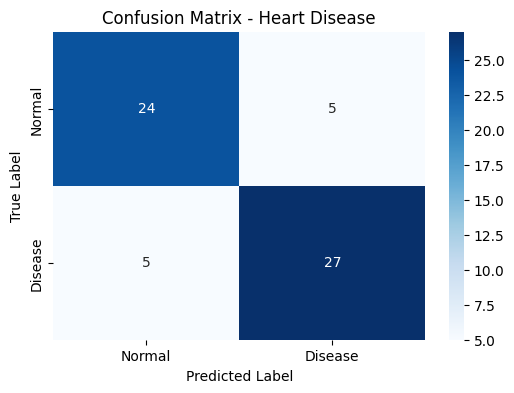

Accuracy: 0.8361
F1-score: 0.8438


In [ ]:
# 1. 테스트 데이터 성능 측정
print("### Dataset 1: Classification Performance ###")
print(classification_report(y_test, y_pred))

# 2. 혼동 행렬(Confusion Matrix) 계산 및 시각화
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Disease'],
            yticklabels=['Normal', 'Disease'])
plt.title('Confusion Matrix - Heart Disease')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# 3. 주요 지표 별도 출력 (해석 준비용)
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"F1-score: {f1_score(y_test, y_pred):.4f}")

## 7) 결과 해석




- 사용한 평가 지표 및 선정 이유:
  - 사용한 지표 : Accuracy, Recall, F1-score
  - 선정 이유 : 데이터셋의 클래스 분포가 비교적 균등하여 Accuracy를 통해 전반적인 분류 성능을 파악하였습니다. 의료 진단 데이터가 실제 환자를 정상으로 오진하는 위험을 최소화하기 위해 Precision보다 Recall 지표로 검토하였으며, Accuracy와 Recall의 균형을 확인하기 위해 F1-score를 최종 지표로 선정하였습니다.

- 최종 결과 및 간단한 해석:
  - 최종 성능 : Accuracy **0.8361**, F1-score **0.8438**
  - 결과 해석 : 소규모 샘플(303개)이지만 84% 수준으로 높은 F1-score를 달성한 것으로 보아 Logistic Regression이 데이터의 전반적인 경향을 안정적으로 학습하였음을 확인할 수 있습니다. 또한, Confusion Matrix 분석 결과 특정 클래스에 편향되지 않은 오차 분포를 보이고 있어 실제 임상 보조 도구로서의 활용 가능성을 확인하였습니다.
---
총평 : 데이터의 규모가 작아 발생할 수 있는 Overfitting 문제를 Logistic Regression의 Regularization과 단순한 구조를 통해 방지하였고, 이는 모델의 복잡도보다 단순하면서 해석 가능한 모델이 더 적합할 수 있음을 확인하였습니다.

---
# 데이터셋 2


## 1) 데이터셋 설명



- 데이터 출처/의미 : 자동차의 가격, 유지비, 기술적 사양 등을 바탕으로 해당 자동차에 대한 구매자들의 만족도(심층 평가 등급)를 분류하는 정형 데이터셋입니다.

- 샘플 수/피처 수 : 샘플 수 1728개, 피처 수 6개

- 타깃 변수(클래스) 설명 : class 열을 타깃으로 하며, 자동차의 상태에 따라 unacc, acc, good, vgood의 4가지 범주를 가지는 Multi-class Classification 데이터입니다.

- 데이터 타입 특징 : 모든 피처가 수치가 아닌 문자열 형태의 범주형 데이터입니다. 또한, 각 변수 내에서 등급 간의 순서가 존재합니다.

- 예상되는 어려움 : 피처가 모두 범주형 데이터이기 때문에 원-핫 인코딩 또는 레이블 인코딩과 같은 전처리가 필수일거라 생각합니다. 또한 'unacc' 클래스의 비중이 매우 높은 클래스 불균형 문제에 대한 해결이 필요할 것 같습니다.

## 2) 데이터 불러오기 및 기본 확인
- 파일 경로/형식(csv 등)과 로딩 방법을 설명한다.
- `shape`, `head()`, 결측치 개수, 타깃 분포 등을 확인하고 요약한다.


In [ ]:
DATASET2_PATH = "/content/sample_data/car_evaluation.csv"  # 예시

df2 = pd.read_csv(DATASET2_PATH)

display(df2.head())
print("shape:", df2.shape)
print("dtypes:\n", df2.dtypes)
print("missing values (sum):\n", df2.isna().sum().sort_values(ascending=False).head(10))


,buying,maint,doors,persons,lug_boot,safety,class
0,vhigh,vhigh,2,2,small,low,unacc
1,vhigh,vhigh,2,2,small,med,unacc
2,vhigh,vhigh,2,2,small,high,unacc
3,vhigh,vhigh,2,2,med,low,unacc
4,vhigh,vhigh,2,2,med,med,unacc


shape: (1728, 7)
dtypes:
 buying      object
maint       object
doors       object
persons     object
lug_boot    object
safety      object
class       object
dtype: object
missing values (sum):
 buying      0
maint       0
doors       0
persons     0
lug_boot    0
safety      0
class       0
dtype: int64


## 3) 전처리 과정 설명
- 수행한 전처리 내용을 작성한다.
- 각 전처리가 왜 필요한지 간단히 설명한다.
- 예: 결측치 처리, 범주형 변수 인코딩, 불필요한 변수 제거


In [ ]:
# 1. 독립변수(X)와 타깃(y) 분리
X = df2.drop('class', axis=1)
y = df2['class']

# 2. 범주형 변수 전처리 설정
# 모든 피처가 문자열이므로 모델 연산을 위해 원-핫 인코딩 적용
categorical_features = X.columns.tolist()
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ])

# 3. 데이터 분할
# 모델의 일반화 성능 검증을 위해 학습용 8, 테스트용 2로 분리
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE)
print(f"학습 데이터 크기: {X_train.shape}")
print(f"테스트 데이터 크기: {X_test.shape}")

# 범주형 변수 인코딩 :
# doors나 persons 컬럼에 '5-more'같은 비수치 데이터가 포함되어 있어, 선형 결합 기반 학습인 Logistic Regression은 잘못된 순서 관계를 학습할 수 있음
# 이를 인식할 수 있도록 수치형 벡터로 변환하는 과정이 필요

# 데이터 분할 :
# 학습에 사용되지 않은 데이터에 대한 모델의 성능을 평가하고, Overfitting 여부 확인을 위해 데이터 분리

# 결측치 확인 : 탐색 결과 결측치가 존재하지 않아 데이터의 원본성 유지

학습 데이터 크기: (1382, 6)
테스트 데이터 크기: (346, 6)


## 4) 모델 선택 설명


선택한 모델 : Logistic Regression

- 선택 이유:
  - 다중 분류 적합성 : 데이터셋은 4개의 클래스를 분류해야 하는 다중 분류 문제이고, Logistic Regression은 Softmax 함수를 통해 다수 클래스 간의 확률적 결정 경계를 안정적으로 도출할 수 있습니다.
  - 피처 구조의 단순성 : 독립 변수가 6개로 적고 모두 범주형이라, 원-핫 인코딩 후 선형 모델을 적용했을 때 각 범주가 타깃 클래스에 미치는 영향력을 파악하기 쉽습니다.

- 선택하지 않은 모델 1 : Decision Tree
  - 선택하지 않은 이유 : 범주형 변수가 많은 데이터에서 결정 트리는 특정 노드에서 데이터가 급격히 분할되어 Overfitting이 발생할 위험이 큽니다. 이로 인해 테스트 데이터에 대한 일반화 성능이 저하될 수 있습니다.

- 선택하지 않은 모델 2 : Random Forest
  - 선택하지 않은 이유 : 데이터셋의 피처 수가 너무 적어서 앙상블 모델을 통한 복잡한 학습보다는 단일 모델의 효율성이 더 높습니다. 또한, 모델의 복잡도가 높아질수록 클래스 불균형 문제에서 다수 클래스(unacc)에 더욱 편향될 수 있습니다.

## 5) 선택한 모델 구현
- 전처리 파이프라인과 결합하여 학습 가능한 형태로 구성한다.
- **주의:** 세 모델을 동시에 비교/튜닝하는 코드는 작성하지 않는다.


In [ ]:
# 1. 모델 선택 및 할당
model_2 = LogisticRegression(random_state=RANDOM_STATE)

# 2. 전처리 파이프라인과 모델 결합
clf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', model_2)
])

# 3. 모델 학습
clf_pipeline.fit(X_train, y_train)

# 4. 예측 수행
y_pred = clf_pipeline.predict(X_test)

# 5. 결과 출력 (Dataset 1과 동일한 양식)
print("### Dataset 2: Car Evaluation Performance ###")
print(classification_report(y_test, y_pred))

# 최종 Accuracy와 F1-score 출력
acc_val = accuracy_score(y_test, y_pred)
# 다중 분류 및 클래스 불균형을 고려하여 weighted f1-score 사용
f1_val = f1_score(y_test, y_pred, average='weighted')

print(f"Accuracy: {acc_val:.4f}")
print(f"F1-score: {f1_val:.4f}")

### Dataset 2: Car Evaluation Performance ###
              precision    recall  f1-score   support

         acc       0.84      0.82      0.83        83
        good       0.50      0.55      0.52        11
       unacc       0.96      0.97      0.97       235
       vgood       0.94      0.88      0.91        17

    accuracy                           0.92       346
   macro avg       0.81      0.80      0.81       346
weighted avg       0.92      0.92      0.92       346

Accuracy: 0.9162
F1-score: 0.9163


## 6) 모델 학습 및 평가
- 학습을 수행하고, 테스트 데이터에서 성능 지표를 계산한다.
- 성능 수치 자체보다 **지표가 의미하는 바를 해석**할 준비를 한다.


### Dataset 2: Car Evaluation Performance ###
              precision    recall  f1-score   support

         acc       0.84      0.82      0.83        83
        good       0.50      0.55      0.52        11
       unacc       0.96      0.97      0.97       235
       vgood       0.94      0.88      0.91        17

    accuracy                           0.92       346
   macro avg       0.81      0.80      0.81       346
weighted avg       0.92      0.92      0.92       346

최종 Accuracy: 0.9162
최종 F1-score (Weighted): 0.9163


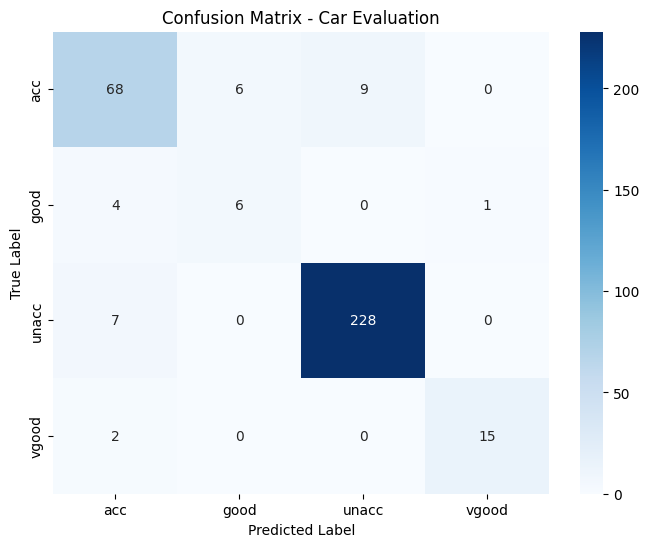

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
import seaborn as sns
import matplotlib.pyplot as plt

# 1. 모델 학습 수행
# Pipeline을 통해 전처리(One-Hot Encoding)와 모델 학습을 한 번에 실행
clf_pipeline.fit(X_train, y_train)

# 2. 테스트 데이터 예측
y_pred = clf_pipeline.predict(X_test)

# 3. 성능 지표 출력 (텍스트 결과)
print("### Dataset 2: Car Evaluation Performance ###")
# 클래스별 정밀도, 재현율, F1-score 등을 확인하여 클래스 불균형 영향 파악
print(classification_report(y_test, y_pred))

acc_val = accuracy_score(y_test, y_pred)
f1_val = f1_score(y_test, y_pred, average='weighted')
print(f"최종 Accuracy: {acc_val:.4f}")
print(f"최종 F1-score (Weighted): {f1_val:.4f}")

# 4. 혼동 행렬(Confusion Matrix) 시각화
# 모델이 어떤 클래스를 헷갈려 하는지 시각적으로 분석하기 위함
plt.figure(figsize=(8, 6))
target_names = ['acc', 'good', 'unacc', 'vgood'] # 데이터셋의 실제 클래스 순서
cm = confusion_matrix(y_test, y_pred, labels=target_names)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=target_names,
            yticklabels=target_names)

plt.title('Confusion Matrix - Car Evaluation')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

## 7) 결과 해석




- 사용한 평가 지표와 왜 해당 지표를
사용하였는지 작성
  - 사용한 지표 : Accuracy, Weighted F1-score
  - 선정 이유 : unacc 클래스가 전체의 약 70%를 차지하는 클래스 불균형 데이터입니다. 이러면 다수 클래스만 잘 맞추어도 정확도가 높게 나올 수 있기 때문에 각 클래스의 샘플 수를 가중치로 반영하여, 소수 클래스의 성능까지 객관적으로 평가할 수 있는 Weighted F1-score를 핵심 지표로 사용하였습니다.

- 최종 결과 및 간단한 해석
  - 최종 성능 : Accuracy **0.9162**, Weighted F1-score **0.9163**
  - 모델의 유효성 : 6개의 범주형 피처로 91%의 정확도가 나온 것은 자동차의 가격, 안전도 등의 속성이 만족도 등급과 타깃 클래스 구분에 유의미한 정보를 제공하고 있음을 나타냅니다.
  - 클래스별 성능 분석 : 샘플 수가 많은 unacc 등급은 F1-score **0.97**로 거의 완벽하게 분류하고 있습니다. 반면 샘플 수가 11개로 가장 적은 good 등급은 F1-score **0.52**로 가장 낮게 나타났습니다. 이는 데이터 불균형으로 인해 모델이 특정 등급을 학습할 사례를 확보하지 못한 현상으로 보입니다.
---
총평 : 모델은 전반적으로 우수한 성능을 보이지만, 성능 개선을 위해서는 데이터 증강이나 오버샘플링 등을 통해 소수 클래스의 재현율을 높이는 작업이 필요할 것으로 보입니다.

---
# 데이터셋 3


## 1) 데이터셋 설명



- 데이터 출처/의미 : 위조지폐 여부를 식별하기 위한 데이터셋입니다. 실제 지폐와 위조지폐 이미지에서 추출한 Wavelet Transform 특징들을 바탕으로 해당 지폐가 진본인지 위조인지 분류합니다.

- 샘플 수/피처 수 : 샘플 수 1372개, 피처 수 4개

- 타깃 변수(클래스)설명 : class 열을 타깃으로 하며 0(진본, Authentic)과 1(위조, Fake)로 나뉘는 이진 분류 데이터입니다.

- 데이터 타입 특징 : 모든 피처가 실수형으로 구성된 수치형 데이터입니다.

- 예상되는 어려움 :
  - 스케일 차이 : 각 피처마다 값의 범위가 다르기 때문에, 선형 모델을 사용할 경우 데이터 표준화 작업이 성능에 큰 영향을 미칠 수 있습니다.
  - 특징 간 상관관계 : 수치형 데이터인 만큼 피처 간의 상관관계가 존재할 수 있으며, 특정 피처가 타깃을 결정짓는 역할을 하는지 확인 필요할 것 같습니다.

## 2) 데이터 불러오기 및 기본 확인
- 파일 경로/형식(csv 등)과 로딩 방법을 설명한다.
- `shape`, `head()`, 결측치 개수, 타깃 분포 등을 확인하고 요약한다.


In [ ]:
DATASET3_PATH = "/content/sample_data/banknote_authentication.csv"  # 예시

df3 = pd.read_csv(DATASET3_PATH)

display(df3.head())
print("shape:", df3.shape)
print("dtypes:\n", df3.dtypes)
print("missing values (sum):\n", df3.isna().sum().sort_values(ascending=False).head(10))


,variance,skewness,curtosis,entropy,class
0,3.62160,8.6661,-2.8073,-0.44699,0
1,4.54590,8.1674,-2.4586,-1.46210,0
2,3.86600,-2.6383,1.9242,0.10645,0
3,3.45660,9.5228,-4.0112,-3.59440,0
4,0.32924,-4.4552,4.5718,-0.98880,0


shape: (1372, 5)
dtypes:
 variance    float64
skewness    float64
curtosis    float64
entropy     float64
class         int64
dtype: object
missing values (sum):
 variance    0
skewness    0
curtosis    0
entropy     0
class       0
dtype: int64


## 3) 전처리 과정 설명
- 수행한 전처리 내용을 작성한다.
- 각 전처리가 왜 필요한지 간단히 설명한다.
- 예: 결측치 처리, 범주형 변수 인코딩, 불필요한 변수 제거


In [ ]:
# 1. 독립변수(X)와 타깃(y) 분리
# 지폐의 특징값들(variance, skewness 등)을 X로, 위조 여부(class)를 y로 설정
X = df3.drop('class', axis=1)
y = df3['class']

# 2. 수치형 변수 표준화(Standardization) 설정
# 평균을 0, 표준편차를 1로 맞추는 StandardScaler를 사용하여 모델의 학습 안정성을 높임
numeric_features = X.columns.tolist()
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features)
    ])

# 3. 데이터 분할
# 전체 데이터를 학습용 8 테스트용 2로 분리
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE)
print(f"학습 데이터 크기: {X_train.shape}")
print(f"테스트 데이터 크기: {X_test.shape}")

# 데이터 표준화 : variance, skewness 등 각 피처가 가진 범위가 서로 다르기에 StandardScaler를 적용하여 모든 피처를 동일한 중요도로 학습
# 데이터 분할 : 모델이 학습 데이터에만 과하게 최적화되는 것을 방지하고, 새로운 지폐 데이터를 만났을 때의 실제 판별 성능을 측정하기 위해 데이터 분리
# 결측치 확인 : 탐색 결과 결측치가 존재하지 않아 모든 샘플을 분석에 활용

학습 데이터 크기: (1097, 4)
테스트 데이터 크기: (275, 4)


## 4) 모델 선택 설명



선택한 모델 : Logistic Regression
- 선택 이유:
  - 수치형 데이터의 선형 판별 : 모든 독립 변수가 이미지에서 추출된 연속형 수치 데이터입니다. 데이터가 연속형이라 비교적 단순한 구조를 가지므로, 수치간의 선형 결합을 통해 확률을 계산하는 모델이 효율적이라고 판단하였습니다.
  - 데이터 구조의 단순성 : 독립 변수가 4개뿐이라 파라미터가 적은 Logistic Regression이 Overfitting을 방지하고 안정적인 일반화 성능을 제공합니다.
  - 해석 용이성 : 각 피처의 Coefficient를 통해 어떤 통계적 특징이 위조 확률을 높이는지 직관적으로 설명할 수 있습니다.
  - 전처리 적합성 : Standardization을 통해 모든 수치형 피처의 스케일을 맞췄으므로, Logistic Regression이 각 변수의 영향력을 공정하게 학습할 수 있습니다.

- 선택하지 않은 모델 1 : Decision Tree
  - 선택하지 않은 이유 : 결정 트리는 데이터를 수직/수평으로 분할하는 경계를 형성합니다. 이러면 연속적인 수치형 데이터의 경우 미세한 변화를 반영하지 못하고 특정 임계값에서 예측값이 급격히 변하는 불연속적인 결정 경계가 형성될 수 있습니다.

- 선택하지 않은 모델 2 : Random Forest
  - 선택하지 않은 이유 : 데이터의 피처가 4개에 불과하여 변수 무작위 추출의 효과를 기대하기 어렵고, 데이터의 규모에 비해 모델의 복잡도가 너무 높아져 불필요한 노이즈까지 학습할 위험이 있습니다. 또한, 모델의 해석 가능성이 낮아 각 변수의 영향력을 직접적으로 파악하기 어렵습니다.

## 5) 선택한 모델 구현
- 전처리 파이프라인과 결합하여 학습 가능한 형태로 구성한다.
- **주의:** 세 모델을 동시에 비교/튜닝하는 코드는 작성하지 않는다.


In [ ]:
# 1. 모델 정의
model_3 = LogisticRegression(random_state=RANDOM_STATE)

# 2. 전처리 파이프라인과 모델 결합
clf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', model_3)
])

# 3. 모델 학습 수행
clf_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['variance', 'skewness',
                                                   'curtosis', 'entropy'])])),
                ('classifier', LogisticRegression(random_state=42))])

## 6) 모델 학습 및 평가
- 학습을 수행하고, 테스트 데이터에서 성능 지표를 계산한다.
- 성능 수치 자체보다 **지표가 의미하는 바를 해석**할 준비를 한다.


### Dataset 3: Banknote Authentication Performance ###
              precision    recall  f1-score   support

           0       0.99      0.97      0.98       148
           1       0.97      0.98      0.98       127

    accuracy                           0.98       275
   macro avg       0.98      0.98      0.98       275
weighted avg       0.98      0.98      0.98       275

최종 Accuracy: 0.9782
최종 F1-score: 0.9766


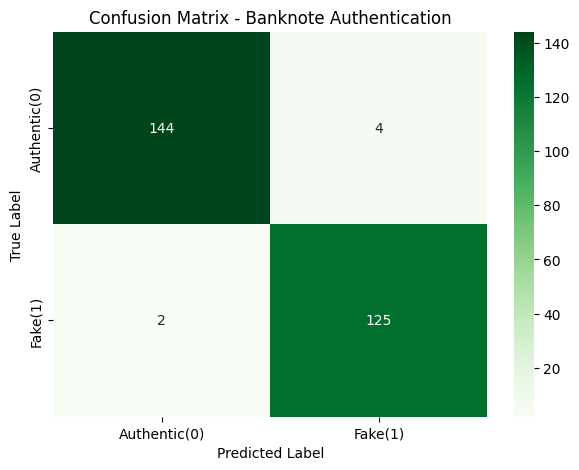

In [ ]:
# 1. 모델 학습 수행
clf_pipeline.fit(X_train, y_train)

# 2. 테스트 데이터 예측
y_pred = clf_pipeline.predict(X_test)

# 3. 성능 지표 출력
print("### Dataset 3: Banknote Authentication Performance ###")

# Precision(정밀도), Recall(재현율), F1-score 리포트 출력
print(classification_report(y_test, y_pred))

acc_3 = accuracy_score(y_test, y_pred)
f1_3 = f1_score(y_test, y_pred) # 이진 분류이므로 기본 f1_score 사용

print(f"최종 Accuracy: {acc_3:.4f}")
print(f"최종 F1-score: {f1_3:.4f}")

# 4. 혼동 행렬(Confusion Matrix) 시각화
plt.figure(figsize=(7, 5))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Authentic(0)', 'Fake(1)'],
            yticklabels=['Authentic(0)', 'Fake(1)'])
plt.title('Confusion Matrix - Banknote Authentication')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

## 7) 결과 해석




- 사용한 평가 지표와 왜 해당 지표를 사용하였는지 작성
  - 사용한 지표 : Accuracy, F1-score, Recall
  - 선정 이유 : 전체적인 분류 성능을 나타내는 정확도도 중요하지만, 위조를 진본으로 판단할 경우 발생하는 사회적 비용이 큽니다. 따라서 모델이 실제 위조지폐를 얼마나 잡아냈는지 확인 하기 위해 Recall을, 정밀도와 재현율의 균형을 보여주는 F1-score를 선정하였습니다.

- 최종 결과 및 간단한 해석
  - 최종 성능 : Accuracy **0.9782**, F1-score **0.9766**
  - 수치형 피처의 유효성 : 이미지의 Wavelet 변환을 통해 추출된 4개의 수치가 위조 여부를 구분 짓는 기준임을 알 수 있습니다. 98%의 성능은 데이터가 비교적 명확한 경계를 가지고 있어 Logistic Regression으로도 높은 분류 성능을 달성할 수 있음을 보여주었고, 각 피처가 위조 여부를 구분하는데 유의미한 정보를 포함하고 있음을 확인할 수 있습니다.
  - 균형 잡힌 성능 : 진본의 F1-score 0.98, 위조의 F1-score 0.98로 모델이 특정 클래스에 편향되지 않고 지폐의 특징을 안정적으로 학습했음을 알 수 있습니다.
---
총평 : Logistic Regression 모델을 사용한 결과 Recall 98%의 높은 성능을 확인할 수 있었습니다. 이는 실제 위조 방지 시스템의 초기 필터링 모델로서 좋은 성능을 보여준다고 볼 수 있습니다. 또한 데이터의 구조와 특성에 적합한 모델을 선택하는 것이 중요한 요소가 됨을 알 수 있었습니다.